# **Proyecto: Análisis exploratorio del Titanic**

Proyecto del módulo de análisis de datos. Se realiza un análisis exploratorio del dataset Titanic, incluyendo recopilación, limpieza, imputación de valores faltantes, visualización de datos y análisis de factores relacionados con la supervivencia.

# Importo las librerias

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Recopilo la información

Para este proyecto se utilizó el conjunto de datos Titanic disponible en la biblioteca Seaborn. Este dataset contiene información de los pasajeros del Titanic, incluyendo variables demográficas, socioeconómicas y el estado de supervivencia.

In [ ]:
df_tit = sns.load_dataset("titanic")

In [ ]:
df_tit.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df_tit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


Este dataset tiene 891 datos en cada una de las 14 columnas. Contiene datos de tipo flotante, entero, object y bool. En algunas hay datos faltantes, veremos como imputar.

# Limpieza de datos

Noto algo importante en el dataframe

In [ ]:
df_tit[["survived","alive"]].head()

,survived,alive
0,0,no
1,1,yes
2,1,yes
3,1,yes
4,0,no


Es una columna redundante, porque contiene la misma información: ¿sobrevivio o no? La eliminamos

In [ ]:
df_tit.drop("alive", axis=1, inplace=True)

## Datos faltantes

Veamos los datos faltantes o nulos

In [ ]:
df_tit.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


Lo muestro como porcentaje

In [ ]:
(df_tit.isnull().sum()/len(df_tit))*100

,0
survived,0.000000
pclass,0.000000
sex,0.000000
age,19.865320
sibsp,0.000000
parch,0.000000
fare,0.000000
embarked,0.224467
class,0.000000
who,0.000000


Se observó que la variable Deck presentaba 688 valores faltantes, lo que representa aproximadamente el 77% de los registros del conjunto de datos. Debido a la gran cantidad de información ausente, se decidió eliminar esta variable del análisis, ya que su conservación podría afectar la calidad de los resultados y aportar información limitada.

In [ ]:
df_tit.drop("deck", axis=1, inplace=True)

Doy una breve descripción estadistica, pero solo de las columnas númericas importantes

In [ ]:
col_num = ["age", "fare"]
col_cat = ["sex", "embarked", "class", "who", "adult_male", "embark_town", "alone"]

df_tit[col_num].describe()

,age,fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


Imputaremos datos númericos de la columna Age, veamos si con la mediana, moda o media

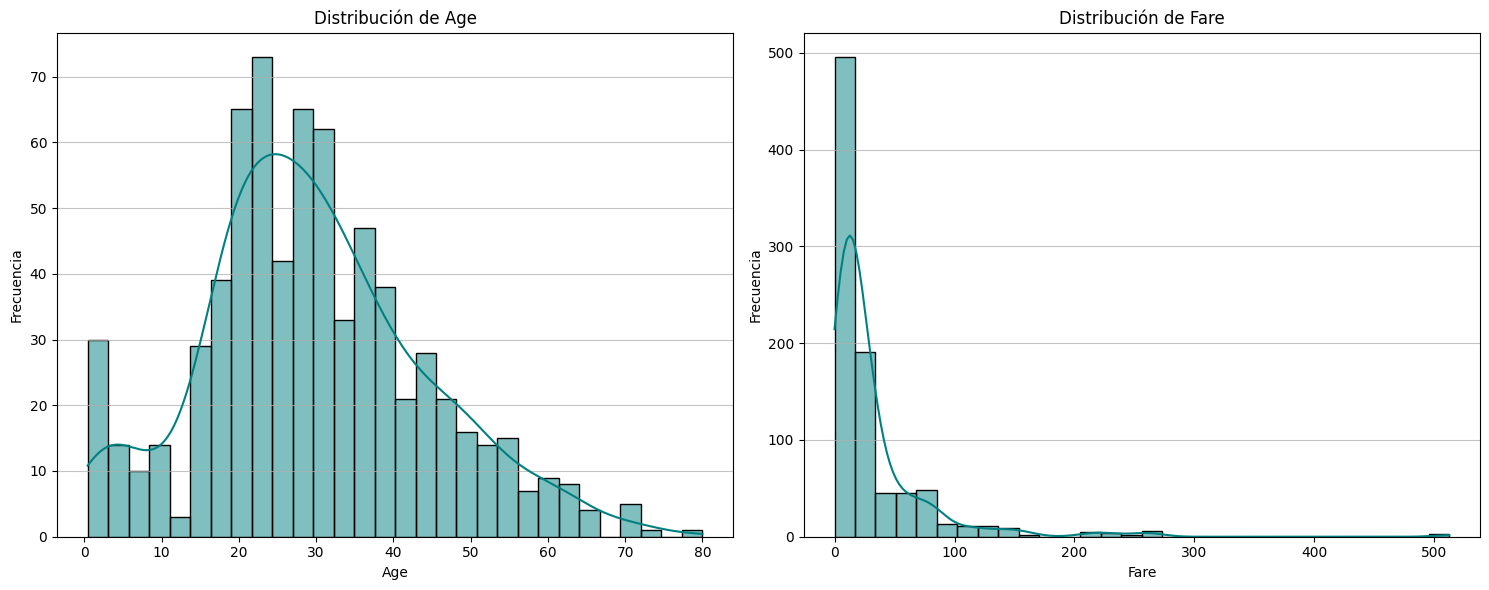

In [ ]:
plt.figure(figsize=(15, 6))

for i, col in enumerate(col_num, 1):
  plt.subplot(1, 2, i)
  sns.histplot(df_tit[col], bins=30, kde=True, color='teal')
  plt.title(f'Distribución de {col.replace("_", " ").title()}')
  plt.xlabel(col.replace("_", " ").title())
  plt.ylabel('Frecuencia')
  plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

Calculemos los promedios y desviación estándar para estimar limites superiores e inferiores.

In [ ]:
media_age = df_tit['age'].mean()
std_age = df_tit['age'].std()

media_fare = df_tit['fare'].mean()
std_fare = df_tit['fare'].std()

lim_sup_age = media_age + std_age
lim_inf_age = media_age - std_age

lim_sup_fare = media_fare + std_fare
lim_inf_fare = media_fare - std_fare

configuracion_age = [(media_age, 'blue'), (lim_sup_age, 'red'), (lim_inf_age, 'red')]
configuracion_fare = [(media_fare, 'blue'), (lim_sup_fare, 'red'), (lim_inf_fare, 'red')]

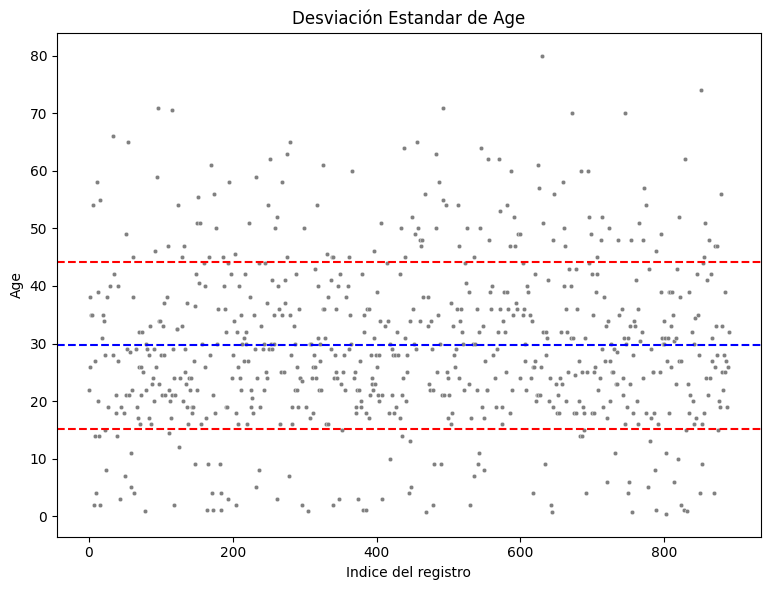

In [ ]:
from matplotlib.lines import lineStyles
# Observar distribución de las columnas con nulos
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x=range(len(df_tit)), y=df_tit['age'], s=10, color='gray')
plt.title('Desviación Estandar de Age')
plt.xlabel('Indice del registro')
plt.ylabel('Age')
for dato, color in configuracion_age:
  plt.axhline(y=dato, color=color, linestyle='--')

plt.tight_layout()
plt.show()


Si bien no se aleja tanto de la media, es mejor la mediana para evitar que los outliers perjudiquen

Ahora una boxplot para confirmar la mediana

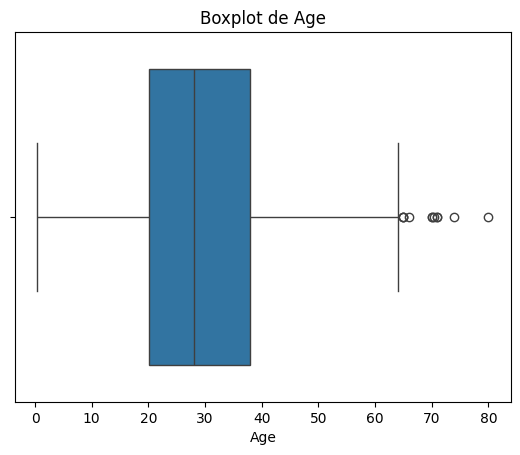

In [ ]:
sns.boxplot(x=df_tit["age"])
plt.title('Boxplot de Age')
plt.xlabel('Age')
plt.show()

Se realizó una revisión de los valores faltantes presentes en el conjunto de datos. Se identificó que la variable Age contenía 177 registros sin información. Para tratar estos valores faltantes, se optó por reemplazarlos utilizando la mediana de la distribución de edades, cuyo valor fue de 28 años.

La mediana fue seleccionada en lugar de la media debido a que es una medida de tendencia central menos sensible a valores extremos y como vemos en el boxplot, hay algunos outliers en la parte de la derecha, por lo que hay varios de edad mayor. Esto proporciona una representación más robusta de la edad típica de los pasajeros. De esta manera, se evitó que edades inusualmente bajas o altas influyeran significativamente en la imputación de los datos faltantes.

In [ ]:
df_tit["age"] = df_tit["age"].fillna(df_tit["age"].median())

In [ ]:
df_tit.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


Con respecto a embarked y embark_town son de tipo texto u `object`

In [ ]:
df_tit[["embarked", "embark_town"]].dtypes

,0
embarked,object
embark_town,object


Imputemos esos dos valores que faltan

In [ ]:
df_tit.groupby("embarked").count()

,survived,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alone
embarked,,,,,,,,,,,,
C,168,168,168,168,168,168,168,168,168,168,168,168
Q,77,77,77,77,77,77,77,77,77,77,77,77
S,644,644,644,644,644,644,644,644,644,644,644,644


Vemos que S es el que más aparece. Transformemoslo a porcentaje

In [ ]:
(df_tit.groupby("embarked")["alone"].count()/len(df_tit))*100

,alone
embarked,
C,18.855219
Q,8.641975
S,72.278339


Lo mejor para estos casos es imputar el dato con la moda. Considerando que son solo 2 datos los nulos

In [ ]:
df_tit["embarked"] = df_tit["embarked"].fillna(df_tit["embarked"].mode()[0])

Solo falta `embark_town`, veamos como se puede imputar

In [ ]:
df_tit.groupby("embark_town").count()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone
embark_town,,,,,,,,,,,,
Cherbourg,168,168,168,168,168,168,168,168,168,168,168,168
Queenstown,77,77,77,77,77,77,77,77,77,77,77,77
Southampton,644,644,644,644,644,644,644,644,644,644,644,644


Vemos que Southampton es el que más aparece. Transformemoslo a porcentaje

In [ ]:
(df_tit.groupby("embark_town")["alone"].count()/len(df_tit))*100

,alone
embark_town,
Cherbourg,18.855219
Queenstown,8.641975
Southampton,72.278339


De igual manera lo mejor para estos casos es imputar el dato con la moda. Considerando que son solo 2 datos los nulos

In [ ]:
df_tit["embark_town"] = df_tit["embark_town"].fillna(df_tit["embark_town"].mode()[0])

Revisamos si queda alguna columna con valores faltantes

In [ ]:
df_tit.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


Todo ha sido limpiado para proceder a extraer la informacion del dataset

# Visualización de datos

<Axes: >

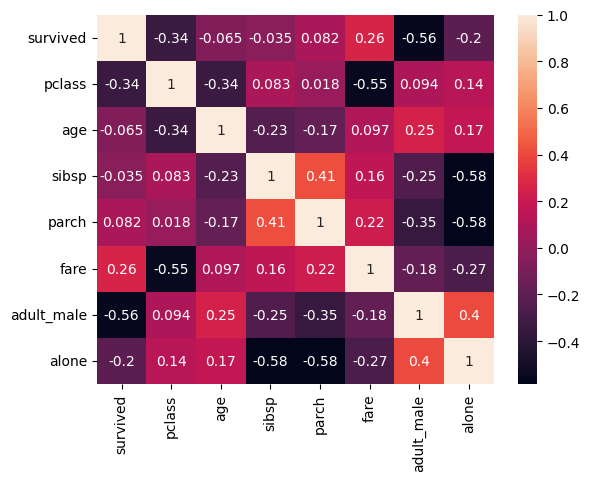

In [ ]:
sns.heatmap(df_tit.corr(numeric_only=True), annot=True)

No se observan correlaciones lineales extremadamente fuertes entre las variables numéricas. Sin embargo, la tarifa presenta una correlación moderada con la clase del pasajero y la supervivencia. Exploremos esto.

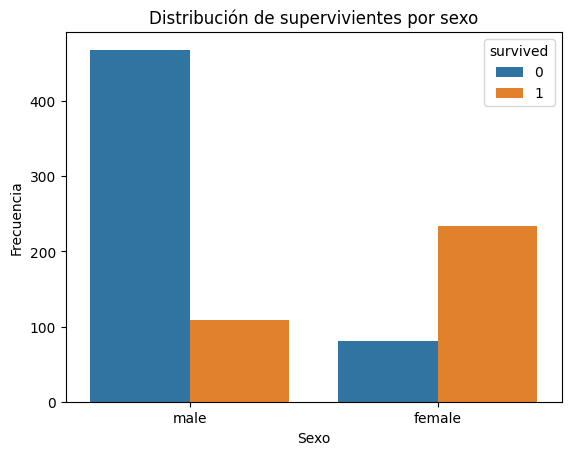

In [ ]:
sns.countplot(x="sex", hue="survived", data=df_tit)
plt.title("Distribución de supervivientes por sexo")
plt.xlabel("Sexo")
plt.ylabel("Frecuencia")
plt.show()

Se observa una diferencia importante en la tasa de supervivencia entre hombres y mujeres. La mayoría de los hombres no sobrevivió al naufragio, mientras que la mayoría de las mujeres sí logró sobrevivir. Esto sugiere que el sexo fue un factor relevante en las probabilidades de supervivencia de los pasajeros del Titanic.

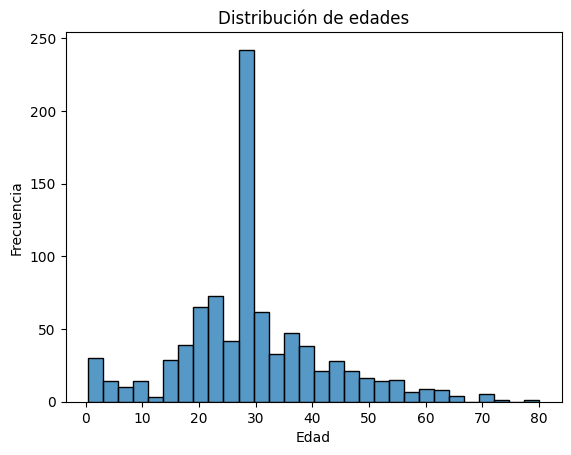

In [ ]:
sns.histplot(df_tit["age"])
plt.title("Distribución de edades")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

La distribución de edades muestra que la mayoría de los pasajeros tenía entre 20 y 40 años, concentrándose especialmente alrededor de los 28 años. También se observa la presencia de niños pequeños y adultos mayores, aunque en menor proporción. La distribución presenta una ligera asimetría hacia la derecha, indicando que existen menos pasajeros en edades avanzadas.

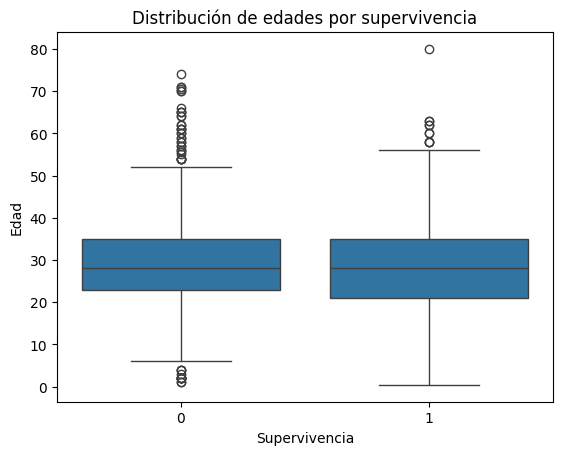

In [ ]:
sns.boxplot(x="survived", y="age", data=df_tit)
plt.title("Distribución de edades por supervivencia")
plt.xlabel("Supervivencia")
plt.ylabel("Edad")
plt.show()

Las distribuciones de edad de sobrevivientes y no sobrevivientes son similares, aunque se observa una mayor presencia de niños entre los sobrevivientes. Y de no sobrevivientes entre las personas mayores.

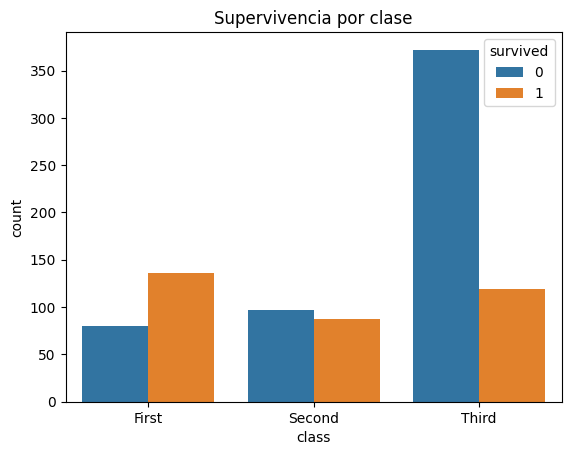

In [ ]:
sns.countplot(data=df_tit, x="class", hue="survived")
plt.title("Supervivencia por clase")
plt.show()

Los pasajeros de primera clase presentaron una mayor tasa de supervivencia que los de segunda y tercera clase. Esto sugiere que la posición socioeconómica pudo influir en las oportunidades de evacuación.

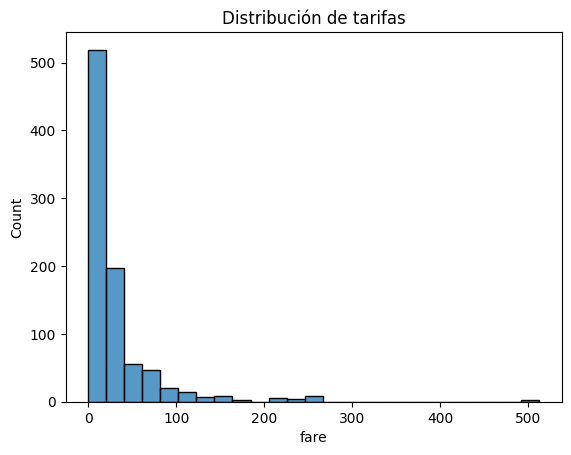

In [ ]:
sns.histplot(df_tit["fare"], bins=25)
plt.title("Distribución de tarifas")
plt.show()

La mayoría de los pasajeros pagó tarifas relativamente bajas, mientras que un pequeño grupo pagó cantidades considerablemente mayores. La distribución presenta una fuerte asimetría positiva.

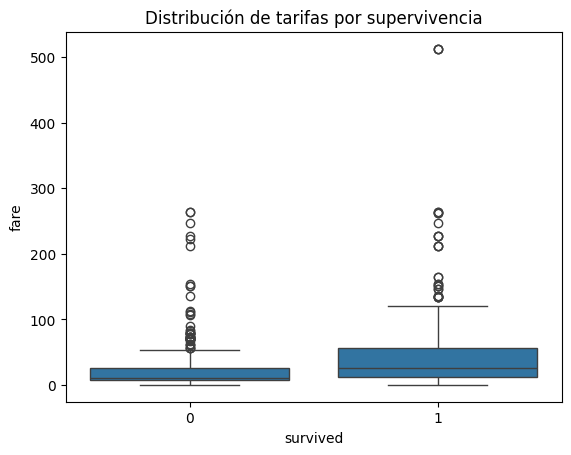

In [ ]:
sns.boxplot(data=df_tit, x="survived", y="fare")
plt.title("Distribución de tarifas por supervivencia")
plt.show()

Los pasajeros que sobrevivieron tendieron a haber pagado tarifas más altas, lo que podría estar relacionado con una mayor presencia de pasajeros de primera clase entre los sobrevivientes.

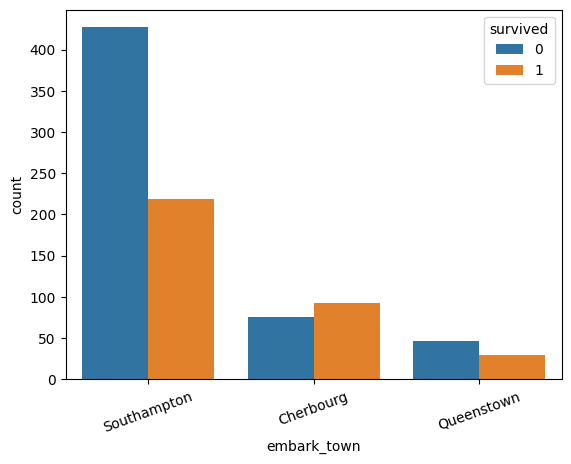

In [ ]:
sns.countplot(data=df_tit, x="embark_town", hue="survived")
plt.xticks(rotation=20)
plt.show()

Existen diferencias en las tasas de supervivencia según el puerto de embarque, aunque estas diferencias podrían estar relacionadas con la distribución de clases sociales en cada puerto. También hay que decir que Southampton fue el principal puerto de embarque.

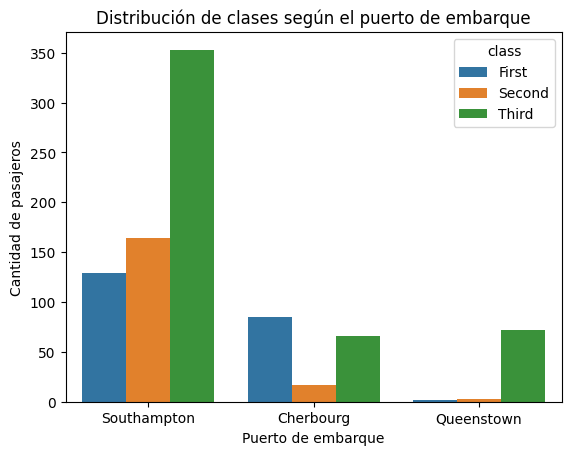

In [ ]:
sns.countplot(data=df_tit, x="embark_town", hue="class")

plt.title("Distribución de clases según el puerto de embarque")
plt.xlabel("Puerto de embarque")
plt.ylabel("Cantidad de pasajeros")

plt.show()

La distribución de pasajeros por clase varía según el puerto de embarque. Southampton fue el puerto con mayor cantidad de pasajeros, predominando la tercera clase. Por otro lado, Cherbourg presentó una mayor proporción de pasajeros de primera clase. Estos resultados sugieren que el puerto de embarque estaba relacionado con el nivel socioeconómico de los pasajeros.